In [85]:
from config import  DATA_DIR,RESULTS_DIR,FIGURS_DIR,METADATA_DIR,RAW_NIFTI_DIR
import pandas as pd
import numpy as np
from util import n4_correction
from adni_preprocess import n4_bias_field_correction,skull_strip,registration,normalize_zscore, resize_image
from pathlib import Path
import SimpleITK as sitk
import matplotlib.pyplot as plt
import os

In [86]:
# NIFTI_DIR = RAW_NIFTI_DIR

# all_nifti_files = [
#     Path(root) / f
#     for root, _, files in os.walk(NIFTI_DIR)
#     for f in files
#     if f.endswith(".nii") or f.endswith(".nii.gz")
# ]

# print(f"Total NIfTI files found: {len(all_nifti_files)}")

# # 1. Initialize your list
# data = []

# # 2. Iterate through your globbed files
# for file_path in all_nifti_files:
#     # Get filename
#     filename = file_path.name 
    
#     # Extract subject_id using your split logic
#     parts = filename.split('_')
    
#     # Safety check: ensure the filename has enough parts before joining
#     if len(parts) > 4:
#         subject_id = "_".join(parts[1:4])
        
#         # Append to our list
#         data.append({
#             "subject_id": subject_id,
#             "file_path": str(file_path)
#         })

# # 3. Create the DataFrame
# df = pd.DataFrame(data)

# # Show the first few rows to verify
# print(f"Total files indexed: {len(df)}")
# df.head()



# # 1. Ensure the directory exists
# RESULTS_DIR = Path(RESULTS_DIR)
# RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# # 2. Define the path for the CSV
# csv_path = RESULTS_DIR / "adni_file_mapping_additional.csv"

# # 3. Save the DataFrame
# # index=False prevents pandas from adding an extra 'Unnamed: 0' column
# df.to_csv(csv_path, index=False)

# print(f"DataFrame saved successfully to: {csv_path}")


In [87]:
# !find /home/ybrima/Data/ADNI -type f | wc -l

In [88]:
!find /home/ybrima/Data/ADNI_Data/ADNI_PROCESSED -type f | wc -l

6523


In [89]:
# !find /home/ybrima/Data/ADNI_Data/ADNI_PROCESSED -type f -iname "*Mask*"

In [90]:
import re
# ==============================================================================
# 1. LOAD DATA
# ==============================================================================

amp_path = Path(DATA_DIR, "ADNIMERGE_05Dec2025.csv")
amp_df = pd.read_csv(amp_path)


preprocessed = DATA_DIR/ "ADNI_PROCESSED"


# Regex for standard ADNI subject ID format: e.g. "011_S_0326"
SUBJECT_ID_PATTERN = re.compile(r"(\d{3}_S_\d{4})")

# glob all nii.gz and nii files in preprocessed directory efficiently
data_dict = {"subject_id": [], "processed_path": []}
nii_files = []
for ext in ["*.nii.gz", "*.nii"]:
    nii_files.extend(preprocessed.glob(ext))

skipped_no_match = []
for file in nii_files:
    if file.exists():
        # IMPORTANT: match against the filename only, not the full path,
        # so unrelated underscores in parent directories can't shift the parse.
        match = SUBJECT_ID_PATTERN.search(file.name)
        if match:
            data_dict["subject_id"].append(match.group(1))
            data_dict["processed_path"].append(str(file))
        else:
            skipped_no_match.append(file.name)

if skipped_no_match:
    print(f"WARNING: {len(skipped_no_match)} files did not match the expected "
          f"subject ID pattern and were skipped. Examples: {skipped_no_match[:5]}")

df_clean = pd.DataFrame(data_dict)


# df_clean = pd.read_csv(RESULTS_DIR / "processed_files_mapping.csv")

# ------------------------------------------------------------------------------
# Basic cleanup
# ------------------------------------------------------------------------------

amp_df = amp_df.rename(columns={
    "PTGENDER": "Sex",
    "DX_bl": "DX_bl",
    "DX": "DX"
})

# Standardize label
amp_df["Group"] = amp_df["DX"].replace({"Dementia": "AD"})

# Parse dates (CRITICAL for correct alignment)
amp_df["EXAMDATE"] = pd.to_datetime(amp_df.get("EXAMDATE"), errors="coerce")

# If MRI has scan date column, use it (must exist or be created earlier)
if "scan_date" in df_clean.columns:
    df_clean["scan_date"] = pd.to_datetime(df_clean["scan_date"], errors="coerce")
else:
    print("WARNING: scan_date not found in MRI metadata.")
    print("Alignment will be approximate (subject-level only).")

# ==============================================================================
# 2. CLEAN MRI TABLE
# ==============================================================================

# Remove missing files
mask_exists = df_clean["processed_path"].apply(lambda x: Path(x).exists())
df_clean = df_clean[mask_exists].reset_index(drop=True)

# Remove duplicates
df_clean = df_clean.drop_duplicates(subset=["processed_path"]).reset_index(drop=True)

# ==============================================================================
# 3. SAFE ALIGNMENT FUNCTION (CORE FIX)
# ==============================================================================

def match_nearest_visit(mri_row, ehr_group):
    """
    Match MRI scan to nearest clinical visit for same subject.
    """
    if "scan_date" not in mri_row or pd.isna(mri_row["scan_date"]):
        # fallback: just take closest row (not ideal but safe fallback)
        return ehr_group.iloc[0]

    ehr_group = ehr_group.dropna(subset=["EXAMDATE"])
    if ehr_group.empty:
        return None

    # compute time distance
    time_diff = (ehr_group["EXAMDATE"] - mri_row["scan_date"]).abs()

    best_idx = time_diff.idxmin()
    return ehr_group.loc[best_idx]

# ==============================================================================
# 4. BUILD PROPER MRI–EHR ALIGNED DATASET
# ==============================================================================

final_rows = []

for subject_id, mri_group in df_clean.groupby("subject_id"):

    ehr_group = amp_df[amp_df["PTID"] == subject_id].copy()

    if ehr_group.empty:
        continue

    ehr_group = ehr_group.sort_values("EXAMDATE")

    for _, mri_row in mri_group.iterrows():

        matched_ehr = match_nearest_visit(mri_row, ehr_group)

        if matched_ehr is None:
            continue

        combined = {
            **mri_row.to_dict(),
            **matched_ehr.to_dict()
        }

        final_rows.append(combined)

final_metadata_df = pd.DataFrame(final_rows)

# ==============================================================================
# 5. FINAL CLEANING + LABELING
# ==============================================================================

final_metadata_df = final_metadata_df.drop_duplicates(subset=["processed_path"])

final_metadata_df = final_metadata_df.dropna(subset=["Group"]).reset_index(drop=True)

# Optional: enforce label mapping consistency
final_metadata_df["Group"] = final_metadata_df["Group"].replace({
    "Dementia": "AD"
})

# ==============================================================================
# 6. VALIDATION CHECKS (VERY IMPORTANT)
# ==============================================================================

print("\n========== ALIGNMENT SANITY CHECK ==========")

print("Total MRI samples:", len(df_clean))
print("Final aligned samples:", len(final_metadata_df))

# Check duplicates
dup = final_metadata_df["processed_path"].duplicated().sum()
print("Duplicate MRI entries:", dup)

# Check subject consistency
if "subject_id" in final_metadata_df.columns:
    inconsistent = final_metadata_df.groupby("subject_id")["Group"].nunique().max()
    print("Max label inconsistency per subject:", inconsistent)

# Check time alignment quality (if available)
if "scan_date" in final_metadata_df.columns and "EXAMDATE" in final_metadata_df.columns:
    final_metadata_df["time_diff_days"] = (
        final_metadata_df["EXAMDATE"] - final_metadata_df["scan_date"]
    ).abs().dt.days

    print("Median time difference (days):",
          final_metadata_df["time_diff_days"].median())

# ==============================================================================
# 7. SAVE FIXED DATASET
# ==============================================================================

out_path = Path(RESULTS_DIR, "ADNI_Combined_Multimodal_FIXED.csv")
final_metadata_df.to_csv(out_path, index=False)

print(f"\nSaved fixed dataset → {out_path}")
print("Final records:", len(final_metadata_df))

/tmp/ipykernel_2989/867764634.py:7: DtypeWarning: Columns (0: ABETA, 1: TAU, 2: PTAU, 3: FLDSTRENG, 4: FSVERSION, 5: ABETA_bl, 6: TAU_bl, 7: PTAU_bl) have mixed types. Specify dtype option on import or set low_memory=False.
  amp_df = pd.read_csv(amp_path)


Alignment will be approximate (subject-level only).

========== ALIGNMENT SANITY CHECK ==========
Total MRI samples: 6522
Final aligned samples: 6479
Duplicate MRI entries: 0
Max label inconsistency per subject: 1

Saved fixed dataset → /home/ybrima/dev/Scripts/results/ADNI_Combined_Multimodal_FIXED.csv
Final records: 6479


In [91]:
print(final_metadata_df['Group'].value_counts(dropna=False))


Group
MCI    3026
CN     2240
AD     1213
Name: count, dtype: int64


In [92]:
import nibabel as nib
idx = np.random.randint(len(final_metadata_df))
nii_file = final_metadata_df["processed_path"].iloc[idx]

img = nib.load(nii_file)
data = img.get_fdata()

print("Image shape:", data.shape)

hdr = img.header

print("Header information:")
print(hdr.get_zooms())
print(hdr.get_xyzt_units())

Image shape: (128, 128, 128)
Header information:
(np.float32(1.1926161), np.float32(1.4749262), np.float32(1.2387075))
('mm', 'sec')


In [93]:
unique_subjects_df = (
    final_metadata_df[['subject_id', 'Group', 'Sex', 'AGE']]
    .drop_duplicates(subset='subject_id')
    .copy()
)
unique_subjects_df['Group'].value_counts()

Group
CN     295
MCI    267
AD     194
Name: count, dtype: int64

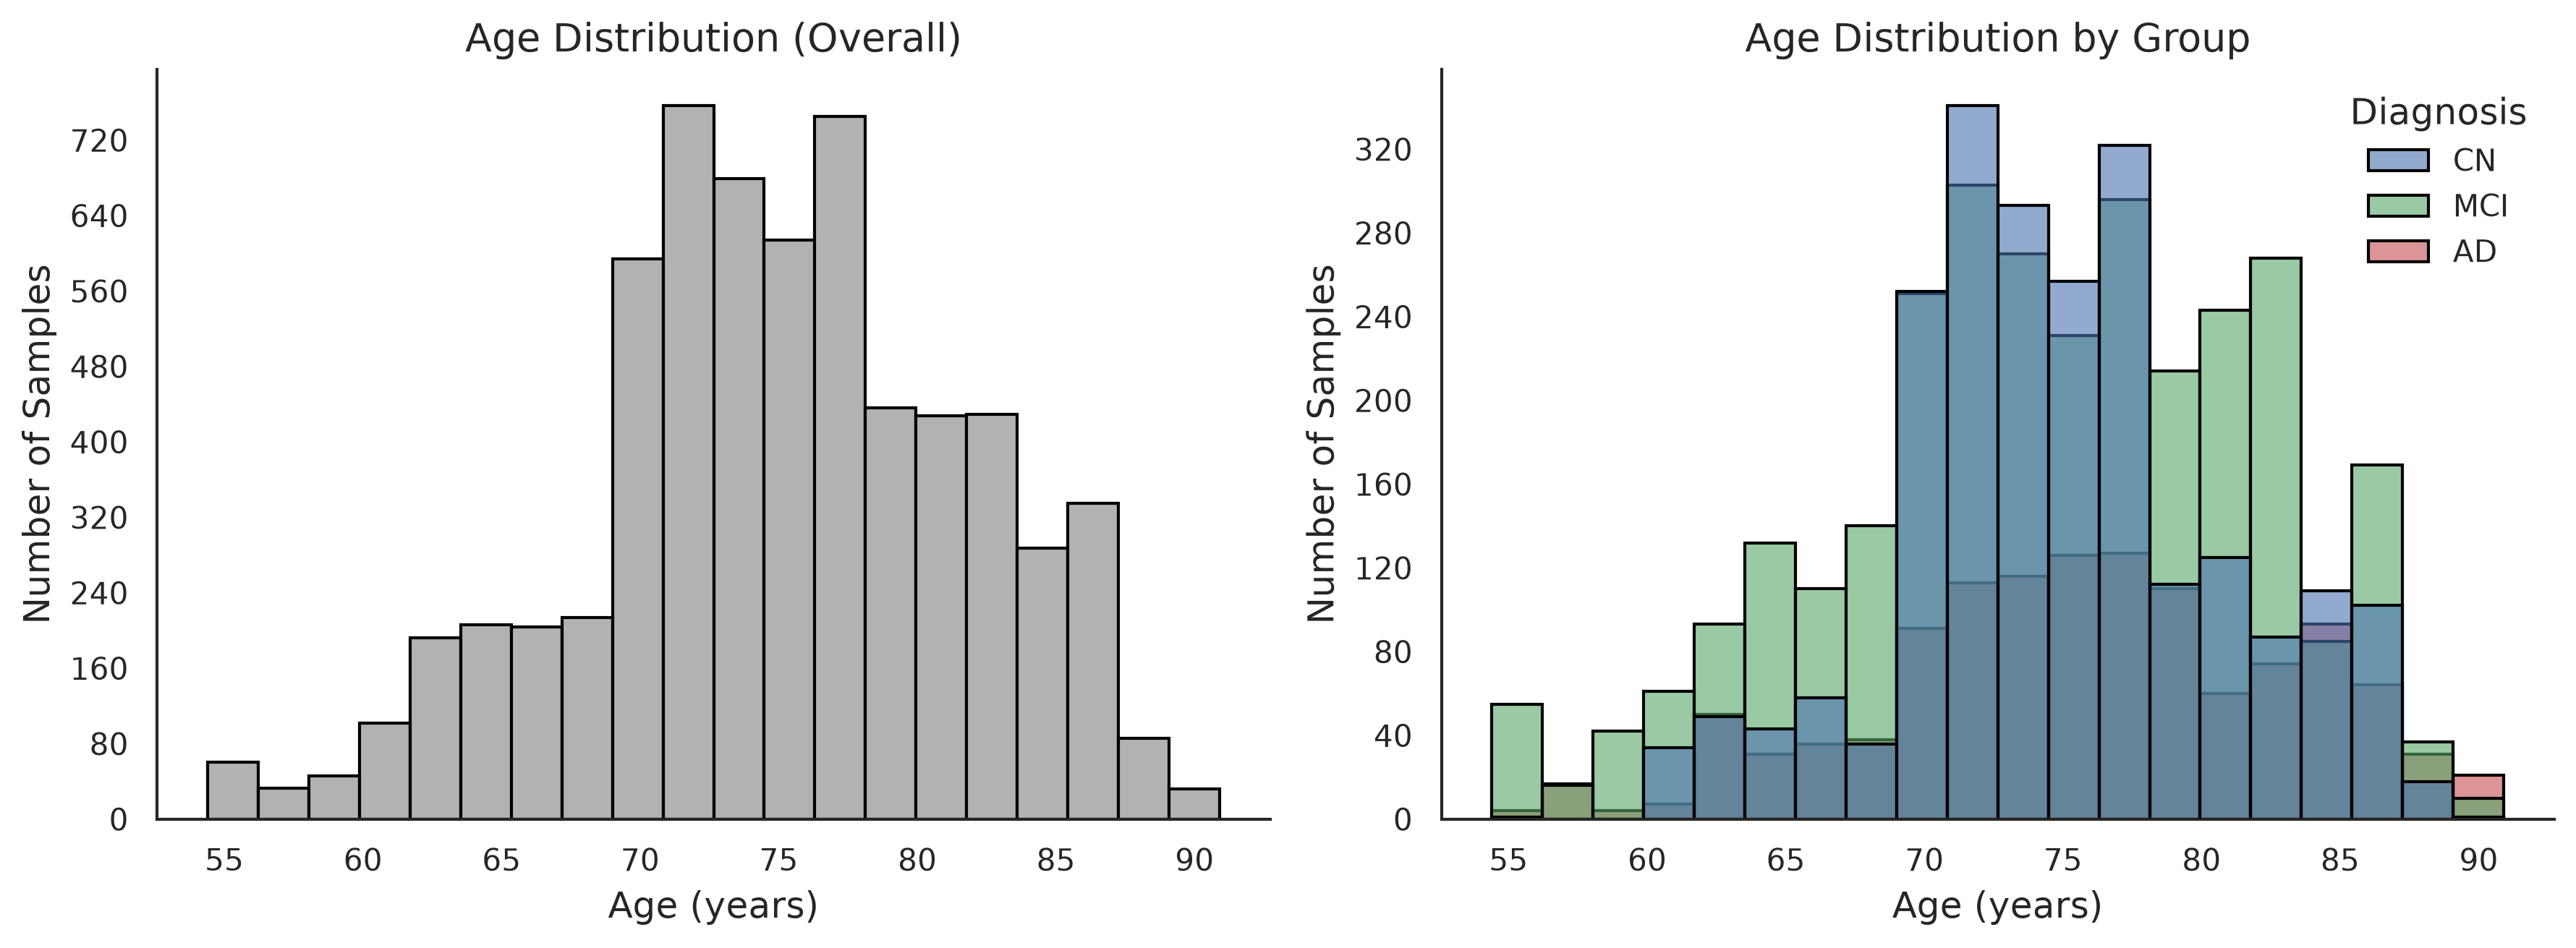

In [94]:

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.ticker import MaxNLocator
from config import DATA_DIR, RESULTS_DIR, FIGURS_DIR, METADATA_DIR
import pandas as pd
from pathlib import Path
# final_metadata_df = pd.read_csv(Path(RESULTS_DIR, "ADNI_Combined_Multimodal_FIXED.csv"))
# Use your matched dataframe
df_to_plot = final_metadata_df

sns.set_theme(style="white")
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "axes.linewidth": 1,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})

# Define specific colors for your ADNI groups
group_colors = {"MCI": "#55A868", "CN": "#4C72B0", "AD": "#C44E52"}

# Consistent bins across plots
bins = np.histogram_bin_edges(df_to_plot["AGE"].dropna(), bins=20)

# ---------------------------
# Plot
# ---------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), dpi=300)

# --- Overall ---
sns.histplot(
    data=df_to_plot,
    x="AGE",
    bins=bins,
    color="gray", # Neutral color for overall
    edgecolor="black",
    alpha=0.6,
    ax=axes[0]
)

axes[0].set_title("Age Distribution (Overall)")
axes[0].set_xlabel("Age (years)")
axes[0].set_ylabel("Number of Samples")

# --- By Group ---
sns.histplot(
    data=df_to_plot,
    x="AGE",
    hue="Group",
    hue_order=["CN", "MCI", "AD"], # Ordered logically
    palette=group_colors,
    bins=bins,
    multiple="layer",
    edgecolor="black",
    alpha=0.6,
    ax=axes[1]
)

axes[1].set_title("Age Distribution by Group")
axes[1].set_xlabel("Age (years)")
axes[1].set_ylabel("Number of Samples")
# Force integer ticks on both y-axes
axes[0].yaxis.set_major_locator(MaxNLocator(integer=True))
axes[1].yaxis.set_major_locator(MaxNLocator(integer=True))
# Adjust Legend
sns.move_legend(
    axes[1],
    "upper right",
    title="Diagnosis",
    frameon=False
)

sns.despine(fig=fig)
plt.tight_layout()
plt.savefig("./figures/age_distribution.pdf", bbox_inches="tight", dpi=300)
plt.show()


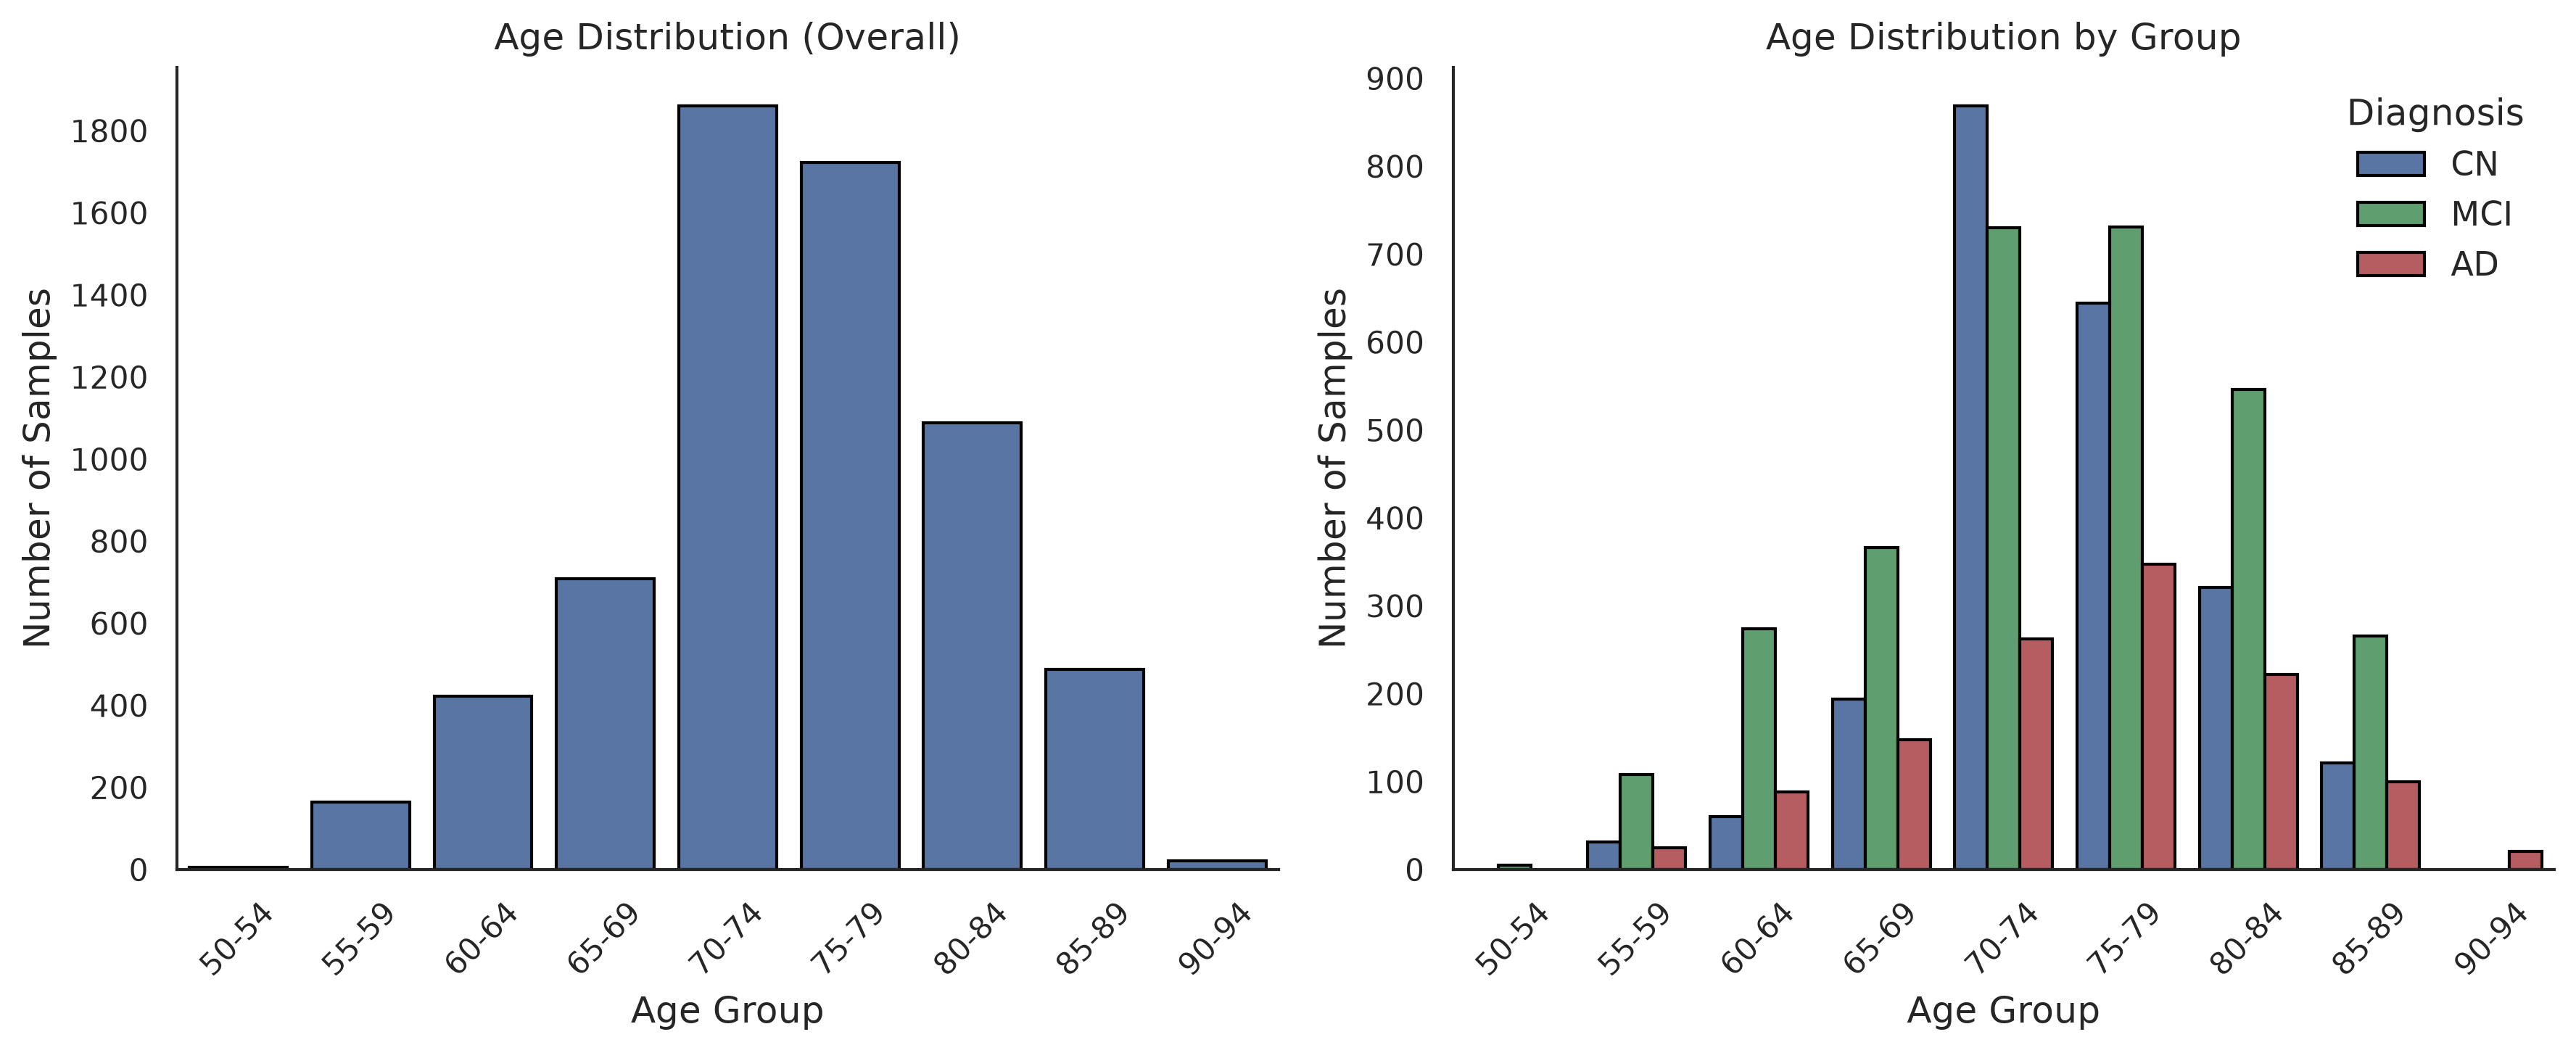

In [95]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# 1. Use your correct dataframe
df_to_plot = final_metadata_df.copy()

# 2. Fix the Bins (5-year intervals)
min_age = int(df_to_plot["AGE"].min()) // 5 * 5
max_age = int(df_to_plot["AGE"].max()) + 5
bins = range(min_age, max_age + 5, 5)
labels = [f"{b}-{b+4}" for b in bins[:-1]]

df_to_plot['Age_group'] = pd.cut(df_to_plot['AGE'], bins=bins, labels=labels, right=False)

# ---------------------------
# Plot Setup
# ---------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=300)
sns.set_theme(style="white")

# --- Plot 1: Overall ---
overall_counts = df_to_plot['Age_group'].value_counts().sort_index().reset_index()
overall_counts.columns = ['Age_group', 'count']

sns.barplot(
    data=overall_counts,
    x="Age_group",
    y="count",
    color="#4C72B0",
    edgecolor="black",
    ax=axes[0]
)
axes[0].set_title("Age Distribution (Overall)")
axes[0].set_xlabel("Age Group")
axes[0].set_ylabel("Number of Samples")

# --- Plot 2: By Group (Grouped Bar Plot) ---
# We calculate counts explicitly to ensure Seaborn handles the bars correctly
group_counts = df_to_plot.groupby(['Age_group', 'Group']).size().reset_index(name='count')

sns.barplot(
    data=group_counts,
    x="Age_group",
    y="count",
    hue="Group",
    hue_order=["CN", "MCI", "AD"], # Consistent clinical order
    palette={"MCI": "#55A868", "CN": "#4C72B0", "AD": "#C44E52"},
    edgecolor="black",
    ax=axes[1]
)
axes[1].set_title("Age Distribution by Group")
axes[1].set_xlabel("Age Group")
axes[1].set_ylabel("Number of Samples")

# ---------------------------
# Final Formatting
# ---------------------------
for ax in axes:
    ax.tick_params(axis='x', rotation=45)
    # FORCE INTEGER TICKS
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))

axes[1].legend(title="Diagnosis", frameon=False, loc="upper right")

sns.despine(fig=fig)
plt.tight_layout()
plt.savefig("./figures/age_distribution_barplot.pdf", bbox_inches='tight', dpi=300)
plt.show()


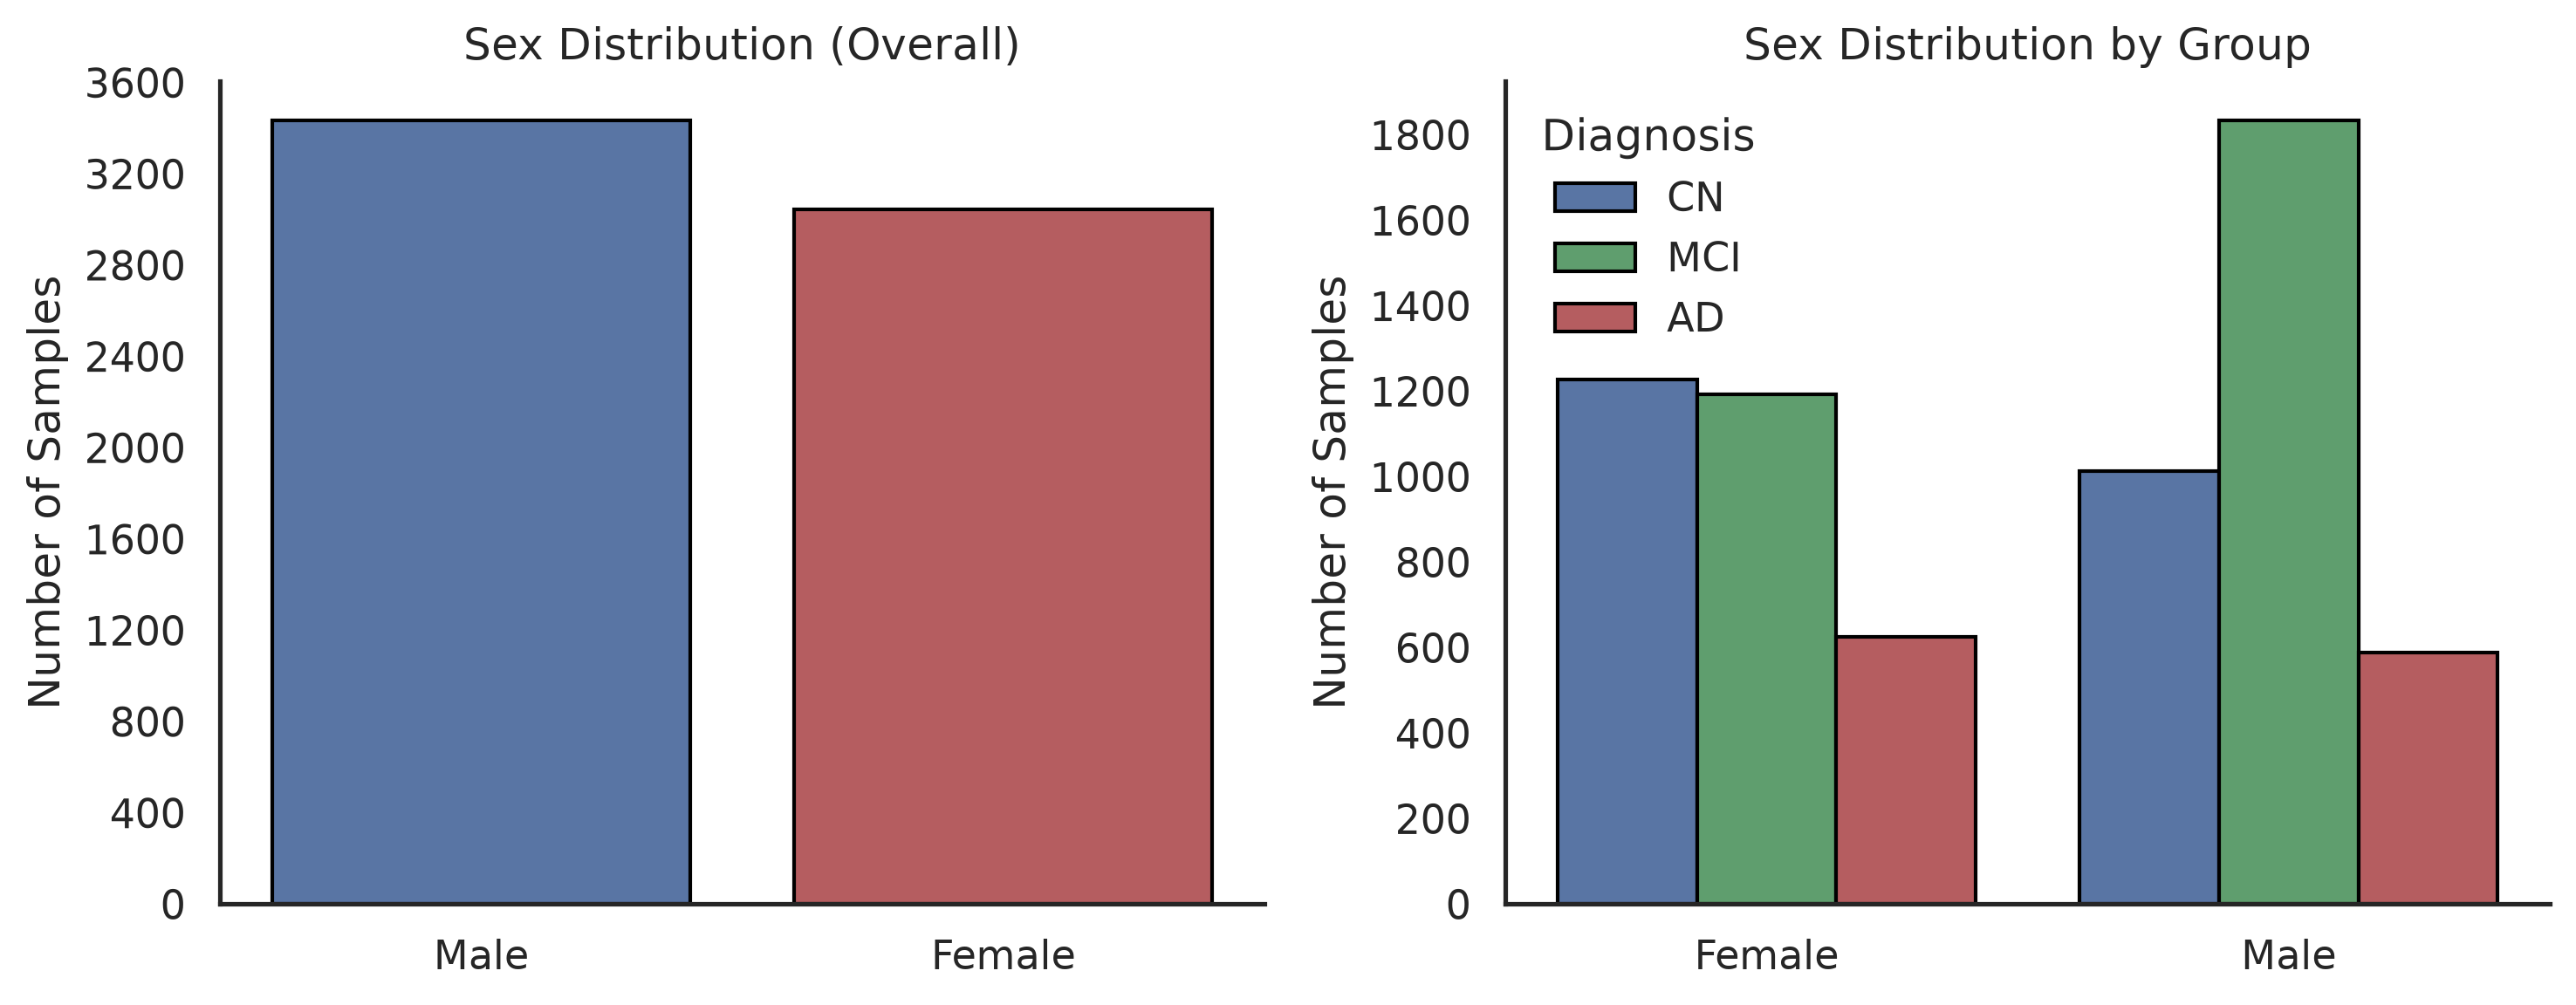

In [96]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MaxNLocator

# 1. Prepare data from your final matched dataframe
df_to_plot = final_metadata_df

sex_counts = df_to_plot["Sex"].value_counts().reset_index()
sex_counts.columns = ["Sex", "Count"]

group_counts = (
    df_to_plot
    .groupby(["Group", "Sex"])
    .size()
    .reset_index(name="Count")
)

# ---------------------------
# Plot
# ---------------------------
fig, axes = plt.subplots(1, 2, figsize=(10, 4), dpi=300)
sns.set_theme(style="white")

# Define color palettes
sex_palette = {"Male": "#4C72B0", "Female": "#C44E52"} # Blue and Red/Pink
group_palette = {"MCI": "#55A868", "CN": "#4C72B0", "AD": "#C44E52"}

# --- Plot 1: Overall (Different colors for Male/Female) ---
sns.barplot(
    data=sex_counts,
    x="Sex",
    y="Count",
    hue="Sex",
    palette=sex_palette,
    legend=False,
    edgecolor="black",
    ax=axes[0]
)
axes[0].set_title("Sex Distribution (Overall)")
axes[0].set_xlabel("")
axes[0].set_ylabel("Number of Samples")

# --- Plot 2: By Group ---
sns.barplot(
    data=group_counts,
    x="Sex",
    y="Count",
    hue="Group",
    hue_order=["CN", "MCI", "AD"],
    palette=group_palette,
    edgecolor="black",
    ax=axes[1]
)

axes[1].set_title("Sex Distribution by Group")
axes[1].set_xlabel("")
axes[1].set_ylabel("Number of Samples")
# axes[1].legend(title="Diagnosis", frameon=False)
axes[1].legend(title="Diagnosis", frameon=False, loc="upper left")

# ---------------------------
# Formatting
# ---------------------------
for ax in axes:
    # Force integer ticks on Y axis
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))

sns.despine(fig=fig)
plt.tight_layout()
plt.savefig("./figures/sex_distribution.pdf", bbox_inches="tight", dpi=300)
plt.show()


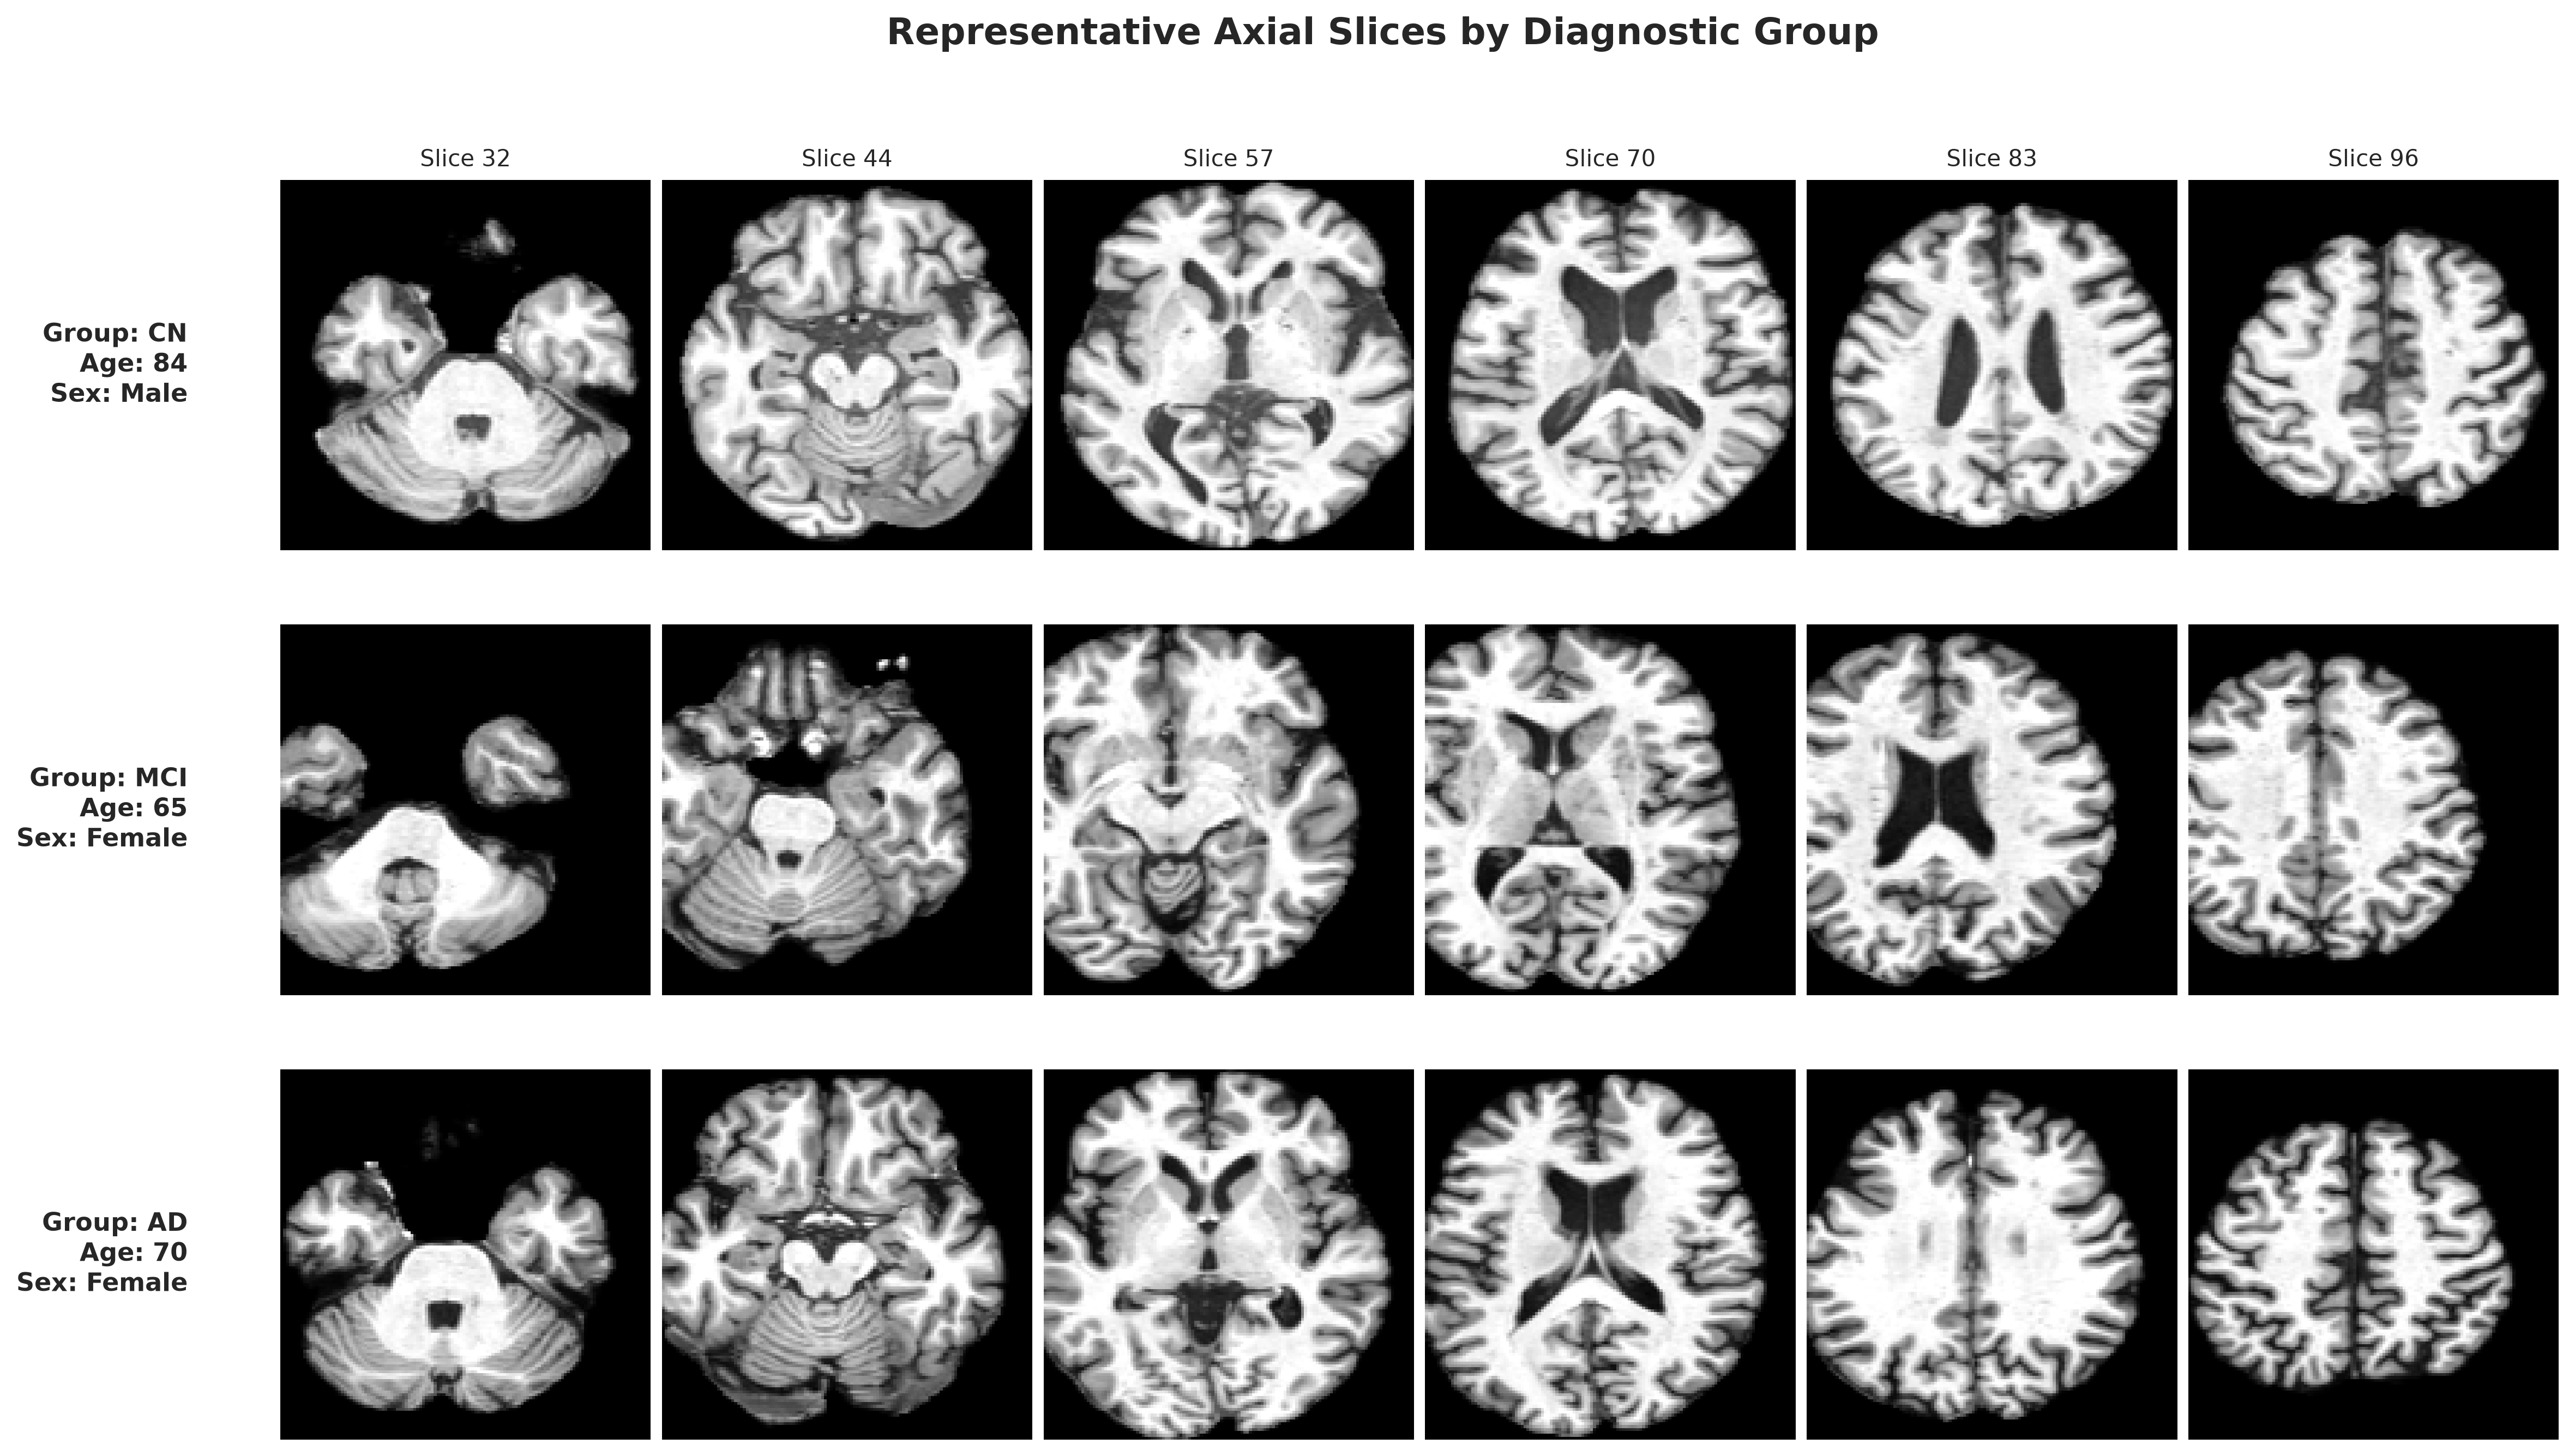

In [98]:
import matplotlib.pyplot as plt
import SimpleITK as sitk
import numpy as np

# Nature-style font settings
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans", "Liberation Sans", "Bitstream Vera Sans"],
    "font.size": 10,
    "svg.fonttype": "none"  # Ensures text remains editable in vector exports
})


classes = ["CN", "MCI", "AD"]
fig, axes = plt.subplots(3, 6, figsize=(18, 10), dpi=300) # Keep DPI high
plt.subplots_adjust(wspace=0.02, hspace=0.2) # Tighten horizontal space

for row_idx, cls in enumerate(classes):
    sample = final_metadata_df[final_metadata_df['Group'] == cls].iloc[0]
    
    img_sitk = sitk.ReadImage(sample['processed_path'])
    img_array = sitk.GetArrayFromImage(img_sitk)
    
    total_slices = img_array.shape[0]
    slice_indices = np.linspace(total_slices // 4, 3 * total_slices // 4, 6).astype(int)
    
    # Text Annotation
    info_text = f"Group: {cls}\nAge: {int(sample['AGE'])}\nSex: {sample['Sex']}"
    axes[row_idx, 0].text(-0.25, 0.5, info_text, transform=axes[row_idx, 0].transAxes,
                          va='center', ha='right', fontsize=11, fontweight='bold')

    for col_idx, s_idx in enumerate(slice_indices):
        ax = axes[row_idx, col_idx]
        
        # FIX: interpolation='nearest' prevents blurring
        # Use vmin/vmax to ignore background noise and highlight tissue
        ax.imshow(img_array[s_idx, :, :], cmap='gray', 
                  origin='lower', interpolation='nearest',
                  vmin=np.percentile(img_array, 2), 
                  vmax=np.percentile(img_array, 98))
        
        ax.axis('off')
        if row_idx == 0:
            ax.set_title(f"Slice {s_idx}", fontsize=10, fontweight='medium')

plt.suptitle("Representative Axial Slices by Diagnostic Group", 
             fontsize=16, fontweight='bold', y=0.98)

# Save as PDF for vector-quality (no pixels) or high-res PNG
plt.savefig("./figures/brain_slices_sharp.pdf", bbox_inches='tight', dpi=300)
plt.show()
